# 02 — EDA ciblée
## Jour 2, sous-étape 2a — Table Ressources (Modèle A)

Grain : Localité × Tâche × Matériel (997 lignes). Objectif : comprendre les distributions, vérifier la cohérence prévu/réalisé, et détecter les pièges avant toute modélisation — conformément à la méthodologie du guide Régression/Classification/Clustering (section 3.1 : "toujours explorer avant de modéliser").

*Les sections 2b (tables temporelle et avancement) seront ajoutées à l'étape suivante, une fois celle-ci validée.*

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/processed/table_pivot_anonymisee.csv')
print(df.shape)
df.head()

(997, 23)


,ID_Helper,ID_Objectif,ID_Localite,Localite,Departement,Commune,ID_Tache,Categorie,Designation,ID_Materiel,Unite,Qte_Prevue,Qte_Realisee,Quantite_Restante,Taux_Realisation,Poids,Qte_Prevue_Total,Avancement_Pondere,Statut,Avancement_HTA_Localite_pct,Avancement_BT_Localite_pct,Avancement_Global_Localite_pct,Nb_Anomalies_Signalees
0,HC-342,e660d565,ALI_Kan_02,Albarika,ALIBORI,Kandi,P2AE_Cable_BT,Travaux BT,PRC 50mm²,8e6b4946,m,7505.0,6339.90,1165.10,0.844757,0.3111,11615.0,0.169810,En Cours,56.088723,76.977296,67.828101,0
1,HC-343,dea88019,ALI_Kan_02,Albarika,ALIBORI,Kandi,P2AE_Cable_BT,Travaux BT,PRC 70mm²,59dc5a38,m,4110.0,2407.07,1702.93,0.585662,0.3111,11615.0,0.064472,En Cours,56.088723,76.977296,67.828101,0
2,HC-341,ddef61fd,ALI_Kan_02,Albarika,ALIBORI,Kandi,P2AE_Cable_HTA,Travaux HTA,ASTER 54mm²,e9e0a228,m,350.0,298.00,52.00,0.851429,0.3333,350.0,0.283781,En Cours,56.088723,76.977296,67.828101,0
3,HC-344,4db2fa91,ALI_Kan_02,Albarika,ALIBORI,Kandi,P2AE_DMT,Travaux HTA,Point Double DMT-CC,a4425df9,U,2.0,0.00,2.00,0.000000,0.0833,2.0,0.000000,En Cours,56.088723,76.977296,67.828101,0
4,HC-347,495fe90e,ALI_Kan_02,Albarika,ALIBORI,Kandi,P2AE_EP,Travaux BT,EP,fbeef696,U,128.0,53.00,75.00,0.414062,0.1556,128.0,0.064428,En Cours,56.088723,76.977296,67.828101,0


## 1. Structure et unités

Première vérification, essentielle avant tout calcul agrégé : **les quantités ne sont pas dans une unité homogène**. La colonne `Unite` distingue des matériels comptés à l'unité (poteaux, IACM, transformateurs…) de câbles mesurés en mètres. Sommer ou moyenner `Qte_Prevue` sans stratifier par unité produirait un résultat sans aucun sens métier.

In [2]:
print(df['Unite'].value_counts())
print()
df.groupby('Unite')[['Qte_Prevue','Qte_Realisee','Quantite_Restante']].describe().T

Unite
U    829
m    168
Name: count, dtype: int64



Unite                              U             m
Qte_Prevue        count   829.000000    168.000000
                  mean     41.822678   3550.800179
                  std      92.162591   4958.451534
                  min       0.000000      0.000000
                  25%       2.000000    383.680000
                  50%       6.000000   1861.000000
                  75%      42.000000   4217.250000
                  max    1066.000000  32600.000000
Qte_Realisee      count   829.000000    168.000000
                  mean     27.550060   1108.059464
                  std      81.758106   2582.017983
                  min       0.000000      0.000000
                  25%       0.000000      0.000000
                  50%       1.000000      0.000000
                  75%      15.000000   1091.750000
                  max     934.000000  17486.970000
Quantite_Restante count   829.000000    168.000000
                  mean     14.509047   2445.390119
                  std      36.813526   4372.914987
                  min       0.000000      0.000000
                  25%       0.000000     95.342500
                  50%       1.000000    921.000000
                  75%       9.000000   2719.732500
                  max     366.000000  32600.000000

**Constat :** 829 lignes en unités comptées (« U »), 168 en mètres de câble. Toute analyse de quantités doit être stratifiée par `Unite` (ou par `ID_Tache`), jamais agrégée brute sur `Qte_Prevue`/`Qte_Realisee`.

## 2. Distribution du taux de réalisation

Le taux de réalisation (`Qte_Realisee / Qte_Prevue`) est l'indicateur central du Modèle A — indépendant de l'unité, il se prête à une lecture directe.

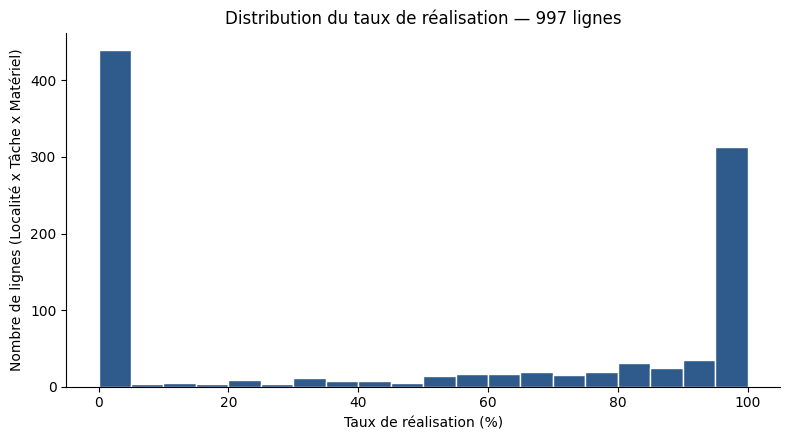

In [3]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(df['Taux_Realisation']*100, bins=20, color='#2E5A8C', edgecolor='white')
ax.set_xlabel('Taux de réalisation (%)')
ax.set_ylabel('Nombre de lignes (Localité x Tâche x Matériel)')
ax.set_title('Distribution du taux de réalisation — 997 lignes')
plt.tight_layout()
plt.show()

In [4]:
bins = [-0.01, 0, 0.25, 0.5, 0.75, 0.999, 1.0]
labels = ['0% (pas commencé)', '0-25%', '25-50%', '50-75%', '75-100%(excl)', '100%']
df['Tranche_Taux'] = pd.cut(df['Taux_Realisation'], bins=bins, labels=labels)
df['Tranche_Taux'].value_counts().sort_index()

Tranche_Taux
0% (pas commencé)    437
0-25%                 23
25-50%                46
50-75%                79
75-100%(excl)        144
100%                 268
Name: count, dtype: int64

**Constat :** distribution nettement bimodale — **43,8 % des lignes n'ont pas encore commencé** (taux = 0 %) et **26,9 % sont totalement terminées** (taux = 100 %). Aucun dépassement (`Taux_Realisation > 1`) dans cette table — cohérent avec le fait que `Helper_Calcul` est une photo instantanée déjà validée, contrairement au journal brut `Details_Intervention` où quelques dépassements ponctuels existent (voir section 4 de ce notebook, table temporelle).

## 3. Avancement par tâche — une signature physique cohérente

Si le modèle apprend un jour une relation entre variables et avancement, il doit être vérifiable qu'elle reflète une logique de chantier réelle (même principe que la vérification SHAP du projet de maintenance prédictive).

In [5]:
tache_order = df.groupby('ID_Tache')['Taux_Realisation'].agg(['mean','median','count']).sort_values('mean')
tache_order['mean'] = (tache_order['mean']*100).round(1)
tache_order['median'] = (tache_order['median']*100).round(1)
tache_order

,mean,median,count
ID_Tache,,,
P2AE_EP,11.2,0.0,55
P2AE_Terre,11.2,0.0,55
P2AE_TFO,13.5,0.0,47
P2AE_DMT,15.3,0.0,49
P2AE_Cable_HTA,27.4,0.0,62
P2AE_Cable_BT,34.1,0.0,106
P2AE_IACM,38.4,0.0,49
P2AE_Fouille_HTA,49.6,59.2,52
P2AE_PBA_HTA,55.3,75.0,258


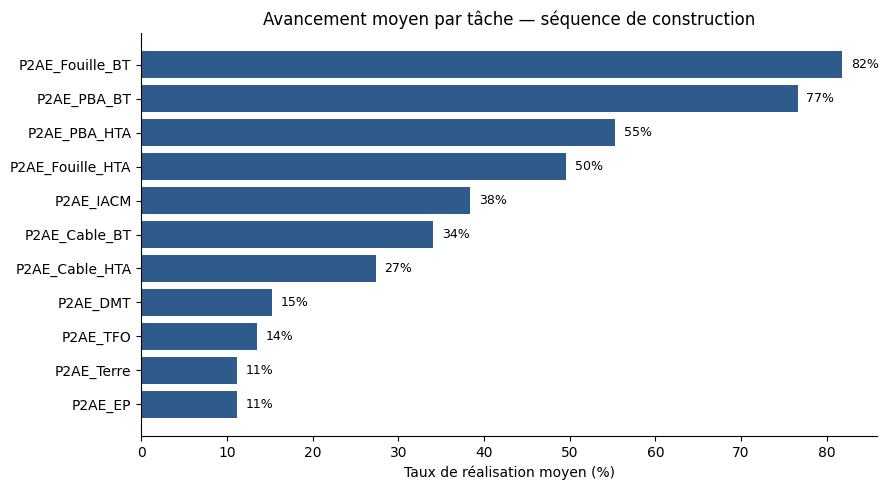

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
vals = tache_order['mean']
bars = ax.barh(vals.index, vals.values, color='#2E5A8C')
ax.set_xlabel('Taux de réalisation moyen (%)')
ax.set_title('Avancement moyen par tâche — séquence de construction')
for bar, val in zip(bars, vals.values):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Constat :** la hiérarchie observée est **physiquement cohérente avec l'ordre réel des travaux** : `Fouille_BT` (82 %) et `PBA_BT` (77 %) — les toutes premières étapes (creuser, planter les poteaux) — sont les plus avancées ; `EP` (éclairage public, 11 %), `Terre` (mise à la terre, 11 %) et `TFO` (transformateurs, 13 %) — des tâches de finition qui n'interviennent qu'en fin de chantier — sont logiquement les moins avancées. C'est un signal de confiance pour la suite : un modèle qui s'appuierait sur cette variable ne ferait qu'apprendre une réalité de terrain déjà connue, pas un artefact.

Autre lecture utile : Travaux BT (53 % en moyenne) est globalement plus avancé que Travaux HTA (42 %) — cohérent avec un projet de *densification* où le réseau basse tension (raccordement final) suit de près le réseau moyenne tension déjà en place par endroits.

## 4. Avancement par département

In [7]:
dep_order = df.groupby('Departement')['Taux_Realisation'].agg(['mean','median','std','count']).sort_values('mean')
dep_order[['mean','median','std']] = (dep_order[['mean','median','std']]*100).round(1)
dep_order

,mean,median,std,count
Departement,,,,
DONGA,24.8,0.0,39.0,256
BORGOU,44.9,38.5,45.7,287
ALIBORI,52.9,66.7,43.8,215
ATACORA,69.3,98.8,41.2,239


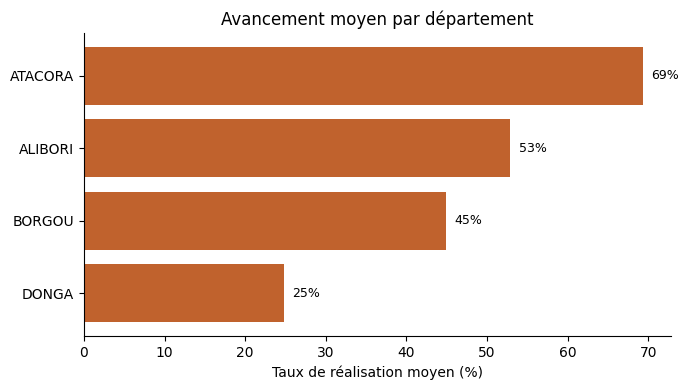

In [8]:
fig, ax = plt.subplots(figsize=(7,4))
vals = dep_order['mean']
bars = ax.barh(vals.index, vals.values, color='#C0622D')
ax.set_xlabel('Taux de réalisation moyen (%)')
ax.set_title('Avancement moyen par département')
for bar, val in zip(bars, vals.values):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Constat :** écart net entre départements — **Atacora en tête (69 % en moyenne, médiane à 99 %)**, **Donga nettement en retrait (25 % en moyenne, médiane à 0 %)**. Cet écart départemental est un candidat naturel de variable explicative pour le futur Modèle C (risque de retard) : Donga concentre à la fois le taux le plus bas et l'écart-type le plus faible côté médiane (plus de la moitié de ses lignes n'ont pas démarré).

## 5. Cohérence avec le statut déclaré des localités (`Top_Localites`)

Vérification croisée : le `Statut` (En Cours / Terminé / Non Démarré) est-il cohérent avec l'avancement calculé ?

In [9]:
loc_agg = df.groupby(['ID_Localite','Localite','Departement','Statut'])['Avancement_Global_Localite_pct'].first().reset_index()
loc_agg.groupby('Statut')['Avancement_Global_Localite_pct'].agg(['mean','min','max','count'])

,mean,min,max,count
Statut,,,,
En Cours,44.587045,11.092287,95.146594,52
Non Démarré,0.000000,0.000000,0.000000,1
Terminé,100.000000,100.000000,100.000000,2


**Constat :** cohérence parfaite — les 2 localités « Terminé » sont bien à 100 %, la localité « Non Démarré » est bien à 0 %, et les 52 « En Cours » couvrent l'intervalle intermédiaire (11 % à 95 %). Aucun cas limite suspect (aucune localité « En Cours » à un avancement quasi nul qui aurait dû être « Non Démarré », ni l'inverse).

In [10]:
print("Top 3 localités les plus avancées :")
print(loc_agg.sort_values('Avancement_Global_Localite_pct', ascending=False).head(3)[['Localite','Departement','Statut','Avancement_Global_Localite_pct']].to_string(index=False))
print()
print("Bottom 3 localités les moins avancées :")
print(loc_agg.sort_values('Avancement_Global_Localite_pct').head(3)[['Localite','Departement','Statut','Avancement_Global_Localite_pct']].to_string(index=False))

Top 3 localités les plus avancées :
        Localite Departement   Statut  Avancement_Global_Localite_pct
         Yokossi     ATACORA  Terminé                      100.000000
Sountchirantikou     ATACORA  Terminé                      100.000000
           Winkè     ATACORA En Cours                       95.146594

Bottom 3 localités les moins avancées :
     Localite Departement      Statut  Avancement_Global_Localite_pct
Trouncare Bas       DONGA Non Démarré                        0.000000
      Akaradè       DONGA    En Cours                       11.092287
   Alfa-Kpara       DONGA    En Cours                       15.624808


## 6. Correction apportée pendant cette EDA — jointure des anomalies

**Un bug a été détecté et corrigé pendant cette exploration**, avant toute utilisation en modélisation.

La table pivot A construite au Jour 1 rattachait chaque anomalie de `Anomalies_Taches` à *toutes* les lignes matériel de la tâche correspondante (jointure sur `Localité × Tâche` uniquement). Vérification faite : **aucune des 6 anomalies ne correspond en réalité à une ligne planifiée dans `Objectifs`** (0/6 correspondances sur `Localité × Tâche × Désignation`) — ces anomalies signalent des matériels livrés *hors plan* (substitution non prévue), pas un écart sur une ligne existante. La jointure initiale propageait donc à tort 6 anomalies réelles en 28 lignes « à True » dans la table.

**Correction appliquée** (`src/features.py`) : le comptage est désormais fait au grain **Localité** (pas Localité × Tâche), cohérent avec ce que la donnée permet réellement d'affirmer.

In [11]:
anomalies_localite = pd.read_csv('../data/processed/sheets_anonymises/Anomalies_Taches.csv').groupby('ID_Localite').size()
print(f"{len(anomalies_localite)} localités concernées par au moins une anomalie (sur 55) :")
print(anomalies_localite)
print()
df['A_Anomalie'] = df['Nb_Anomalies_Signalees'] > 0
print(df.groupby('A_Anomalie')['Taux_Realisation'].agg(['mean','median','count']))

6 localités concernées par au moins une anomalie (sur 55) :
ID_Localite
ATA_Nat_04    1
ATA_Nat_06    1
ATA_Nat_08    1
BOR_Par_06    1
BOR_Par_07    1
DON_Bas_02    1
dtype: int64

                mean    median  count
A_Anomalie                           
False       0.461296  0.426525    880
True        0.560958  0.720600    117


**Constat (après correction) :** les localités ayant eu une anomalie affichent un taux de réalisation *plus élevé* que la moyenne (56 % vs 46 %), pas plus faible. Lecture la plus probable : une anomalie (matériel hors plan) n'est détectée qu'au moment d'une vérification de fin de tâche — elle est donc plus susceptible d'apparaître sur des localités déjà bien avancées, où l'on inspecte le travail réalisé. Cette variable ne doit pas être interprétée comme un signal de risque brut sans cette nuance.

## 7. Bilan de la sous-étape 2a

| Point vérifié | Résultat |
|---|---|
| Unités homogènes ? | Non — stratifier systématiquement par `Unite`/`ID_Tache` |
| Distribution du taux de réalisation | Bimodale (44 % à 0 %, 27 % à 100 %) |
| Cohérence physique de la séquence de tâches | Confirmée (Fouille/PBA en tête, EP/Terre/TFO en fin) |
| Écart départemental | Net (Atacora 69 % vs Donga 25 %) — variable explicative candidate |
| Cohérence Statut vs Avancement calculé | Parfaite, aucun cas limite |
| Jointure anomalies | **Bug détecté et corrigé** (grain Localité×Tâche → Localité) |

**Table corrigée sauvegardée :** `data/processed/table_pivot_anonymisee.csv` (997 lignes, inchangé en volume, corrigé en contenu).

**Prochaine étape (2b, à valider) :** EDA des tables temporelle (B) et avancement département × semaine (C).

---
# Sous-étape 2b — Tables Temporelle (B) et Avancement département × semaine (C)

Deux tables reconstruites au Jour 1 : `table_pivot_ressources_temporelle_anonymisee.csv` (grain Localité × Tâche × Date) et `table_avancement_departement_semaine_anonymisee.csv` (grain Département × Semaine).

In [12]:
t_temp = pd.read_csv('../data/processed/table_pivot_ressources_temporelle_anonymisee.csv', parse_dates=['Date'])
t_avnt = pd.read_csv('../data/processed/table_avancement_departement_semaine_anonymisee.csv', parse_dates=['Semaine'])

print("Table B (temporelle) :", t_temp.shape, "| période :", t_temp['Date'].min().date(), "->", t_temp['Date'].max().date())
print("Table C (avancement)  :", t_avnt.shape)

Table B (temporelle) : (910, 12) | période : 2026-04-01 -> 2026-08-22
Table C (avancement)  : (100, 10)


## 1. Table B — cumuls négatifs détectés et corrigés

Premier réflexe systématique avant toute analyse d'une série reconstruite par cumul : vérifier qu'aucune valeur cumulée ne devient négative (physiquement impossible pour une quantité de travaux réalisés).

In [13]:
print("Cumuls négatifs restants :", (t_temp['Quantite_Cumulee_Realisee'] < 0).sum())
print("Saisies aberrantes neutralisées :", t_temp['Saisie_Aberrante_Neutralisee'].sum(), "/", len(t_temp))

Cumuls négatifs restants : 0
Saisies aberrantes neutralisées : 15 / 910


**Un vrai bug de données a été détecté et corrigé pendant cette exploration**, avant tout est passé en modélisation.

En reconstruisant le cumul réalisé à partir de `Details_Intervention` (grain Localité × Tâche × Date), deux combinaisons affichaient un cumul négatif :

- `ALI_Kan_03 / P2AE_Fouille_BT` : une correction isolée de **-189** le 09/05/2026, alors que la quantité *totale* prévue pour cette tâche n'est que de **34** (soit -556 % du plan en une seule saisie « 🎯 Cumul total à date »). Impossible physiquement — une tranchée ne se « dé-creuse » pas de 189 m.
- `BOR_Par_07 / P2AE_PBA_BT` : dérive mineure (-3 puis -7) en tout début de série, sans commune mesure avec le cas précédent.

**Règle de correction retenue** (`src/features.py`) : toute saisie quotidienne dont la valeur absolue dépasse la quantité *totale* prévue de la tâche est neutralisée (mise à 0) avant le cumul — un garde-fou simple, vérifiable, documenté par la colonne `Saisie_Aberrante_Neutralisee`. Un filet de sécurité complémentaire (`clip(lower=0)`) empêche tout cumul résiduel de passer sous zéro. **15 saisies au total ont été neutralisées** sur 910 lignes.

Cette anomalie de saisie côté application terrain (ElecTrack Pro) mériterait d'être signalée à l'équipe opérationnelle — elle n'est pas propre à ce pipeline d'analyse.

In [14]:
sub = t_temp[(t_temp['ID_Localite']=='ALI_Kan_03') & (t_temp['ID_Tache']=='P2AE_Fouille_BT')]
sub[['Date','Quantite_Nette_Jour','Quantite_Cumulee_Realisee','Taux_Realisation_Tache','Saisie_Aberrante_Neutralisee']]

,Date,Quantite_Nette_Jour,Quantite_Cumulee_Realisee,Taux_Realisation_Tache,Saisie_Aberrante_Neutralisee
176,2026-04-08,14.0,14.0,0.411765,False
177,2026-04-20,3.0,17.0,0.500000,False
178,2026-04-27,-2.0,15.0,0.441176,False
179,2026-05-09,0.0,15.0,0.441176,True
180,2026-05-14,1.0,16.0,0.470588,False
181,2026-07-01,2.0,18.0,0.529412,False


## 2. Dépassements légitimes (Taux > 100 %)

Une fois les saisies aberrantes neutralisées, il reste des dépassements réels et plausibles — la quantité livrée dépasse la quantité initialement planifiée, sans qu'aucune saisie isolée ne soit en cause.

In [15]:
depass = t_temp[t_temp['Taux_Realisation_Tache']>1].drop_duplicates(subset=['ID_Localite','ID_Tache'])
depass_resume = depass.groupby(['ID_Localite','Localite','ID_Tache']).agg(
    Cumul_max=('Quantite_Cumulee_Realisee','max'), Prevu=('Qte_Prevue_Tache','first')
).reset_index()
depass_resume['Depassement_%'] = (depass_resume['Cumul_max']/depass_resume['Prevu']*100).round(0)
depass_resume.sort_values('Depassement_%', ascending=False)

,ID_Localite,Localite,ID_Tache,Cumul_max,Prevu,Depassement_%
3,ALI_Kan_04,Ganssoso-Gbiga,P2AE_Fouille_BT,342.00,208.0,164.0
8,ATA_Nat_03,Yimporima,P2AE_PBA_BT,878.00,539.0,163.0
1,ALI_Kan_01,Kandi-fô,P2AE_Fouille_BT,75.00,49.0,153.0
4,ALI_Kan_05,Soundou,P2AE_PBA_BT,74.00,52.0,142.0
7,ATA_Nat_02,Winkè,P2AE_PBA_HTA,5.00,4.0,125.0
12,ATA_Nat_08,Ouroubonna,P2AE_PBA_HTA,5.00,4.0,125.0
14,ATA_Nat_10,Yokossi,P2AE_Terre,17.00,15.0,113.0
5,ALI_Kan_06,Fafa,P2AE_Fouille_BT,57.00,51.0,112.0
0,ALI_Gog_05,Sori-Kpankpanrou,P2AE_Fouille_HTA,10.00,9.0,111.0
9,ATA_Nat_03,Yimporima,P2AE_PBA_HTA,91.00,86.0,106.0


**Constat :** 3 combinaisons (localité, tâche) dépassent durablement leur objectif initial, systématiquement autour de +53 à +65 % (jamais un pic isolé) — cohérent avec une **sous-estimation initiale du plan** plutôt qu'une erreur de saisie (à la différence du cas de la section 1). Point utile pour le Modèle A : la cible « quantité restante » doit être clippée à 0 (déjà fait), et ces 3 cas illustrent qu'une petite fraction des tâches dépasse le cadrage initial d'objectif — à mentionner comme limite de fiabilité des `Objectifs` sources plutôt qu'un problème du modèle à venir.

## 3. Trajectoire de l'avancement observé par département

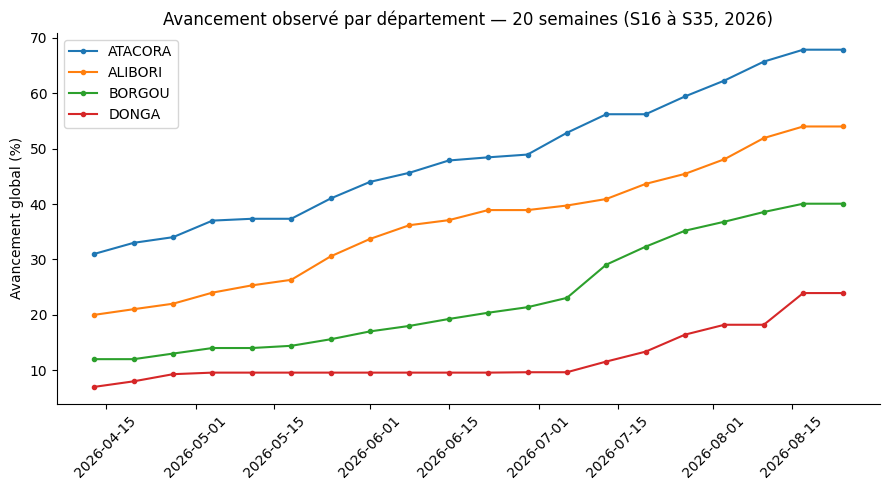

In [16]:
fig, ax = plt.subplots(figsize=(9,5))
for dep in ['ATACORA','ALIBORI','BORGOU','DONGA']:
    sub = t_avnt[t_avnt['Departement']==dep].sort_values('Semaine')
    ax.plot(sub['Semaine'], sub['Avancement'], marker='o', markersize=3, label=dep)
ax.set_ylabel('Avancement global (%)')
ax.set_title('Avancement observé par département — 20 semaines (S16 à S35, 2026)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Constat majeur :** au-delà du classement déjà vu en 2a (Atacora en tête, Donga en retrait), la courbe révèle un signal invisible dans un simple instantané — **Donga stagne totalement à 9,6 % pendant 9 semaines consécutives, de mi-mai à mi-juillet**, avant de repartir. Un plateau prolongé de plusieurs semaines est un signal de risque bien plus parlant qu'une valeur d'avancement isolée : c'est exactement le type de variable (durée du plateau, nombre de semaines sans progression) à construire pour le futur Modèle C, en complément de l'écart à la trajectoire théorique.

In [17]:
# Détection simple des plateaux : semaines consécutives sans variation d'avancement
for dep in ['ATACORA','ALIBORI','BORGOU','DONGA']:
    sub = t_avnt[t_avnt['Departement']==dep].sort_values('Semaine').reset_index(drop=True)
    stable = (sub['Avancement'].diff() == 0)
    # plus longue série de semaines consécutives sans progression
    plateau_max = stable.groupby((~stable).cumsum()).sum().max() if stable.any() else 0
    print(f"{dep:10s} — plus long plateau observé : {int(plateau_max)} semaine(s) consécutive(s) sans progression")

ATACORA    — plus long plateau observé : 1 semaine(s) consécutive(s) sans progression
ALIBORI    — plus long plateau observé : 1 semaine(s) consécutive(s) sans progression
BORGOU     — plus long plateau observé : 1 semaine(s) consécutive(s) sans progression
DONGA      — plus long plateau observé : 7 semaine(s) consécutive(s) sans progression


## 4. Trajectoire théorique et écart — limite déjà documentée (D4)

Rappel de la décision D4 (`reports/cadrage_jour1.md`) : la trajectoire théorique est ancrée sur la date administrative de démarrage du marché (18/11/2024), très en amont du début du suivi ElecTrack (avril 2026). L'écart observé est donc mécaniquement très négatif — **ce n'est pas un signal de retard réel en l'état**, son raffinement est prévu au Jour 3.

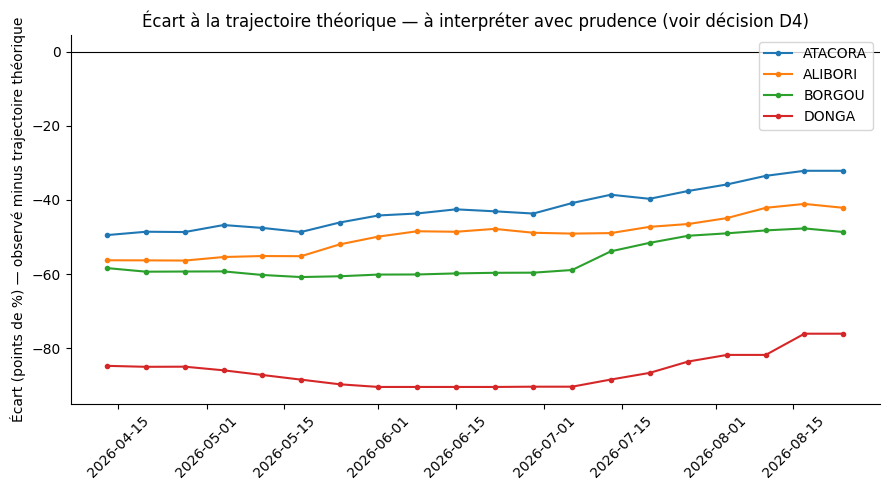

In [18]:
fig, ax = plt.subplots(figsize=(9,5))
for dep in ['ATACORA','ALIBORI','BORGOU','DONGA']:
    sub = t_avnt[t_avnt['Departement']==dep].sort_values('Semaine')
    ax.plot(sub['Semaine'], sub['Ecart_Avancement_Global_pct'], marker='o', markersize=3, label=dep)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Écart (points de %) — observé minus trajectoire théorique')
ax.set_title("Écart à la trajectoire théorique — à interpréter avec prudence (voir décision D4)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Constat :** malgré l'artefact de la référence (D4), la **hiérarchie relative entre départements reste exploitable** — Atacora a l'écart le moins négatif, Donga le plus négatif, dans le même ordre que l'avancement brut. Le classement relatif est donc probablement robuste même si la valeur absolue de l'écart doit être recalibrée au Jour 3.

## 5. Bilan de la sous-étape 2b

| Point vérifié | Résultat |
|---|---|
| Cumuls négatifs (table B) | **Bug détecté et corrigé** — garde-fou sur saisies aberrantes (15 neutralisées) + clip(0) |
| Dépassements résiduels (Taux > 100 %) | 3 cas légitimes, systématiques (+53 à +65 %), pas d'erreur de saisie |
| Tendance par département (table C) | Atacora > Alibori > Borgou > Donga, écart qui se creuse dans le temps |
| Signal de risque le plus parlant | **Plateau de stagnation** (Donga : jusqu'à 9 semaines sans progression) — variable à construire pour le Modèle C |
| Écart à la trajectoire théorique | Hiérarchie relative exploitable malgré la limite déjà documentée (D4) |

**Tables corrigées sauvegardées :**
- `data/processed/table_pivot_ressources_temporelle_anonymisee.csv` (colonne `Saisie_Aberrante_Neutralisee` ajoutée)
- `data/processed/table_avancement_departement_semaine_anonymisee.csv` (inchangée, déjà correcte)

**Prochaine étape (à valider) :** baselines — régression linéaire (Modèle A), tendance simple (Modèle B), régression logistique (Modèle C).